Análise das diferenças de salários entre homens e mulheres no campo de data science no Brasil. A análise tem componentes gráficos e estatístico:
* [Presença em data science (Homens vs Mulheres)](#presenca)
* [Escolaridade e Tipo de emprego para homens e Mulheres: Análise porcentual](#escol)
* [Questão salarial, homens ganham mais do que as mulheres?](#salario)
* [Significância estatística das diferenças](#significancia)
* [Conclusões](#conclusao)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import scipy.stats as st
import matplotlib.patches as mpatches

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pesquisa-data-hackers-2019/data_dictionary.txt
/kaggle/input/pesquisa-data-hackers-2019/datahackers-survey-2019-anonymous-responses.csv


In [ ]:
df_ds = pd.read_csv('/kaggle/input/pesquisa-data-hackers-2019/datahackers-survey-2019-anonymous-responses.csv')
print(df_ds.shape)
df_ds.head()

(1765, 170)


,"('P0', 'id')","('P1', 'age')","('P2', 'gender')","('P3', 'living_in_brasil')","('P5', 'living_state')","('P6', 'born_or_graduated')","('P8', 'degreee_level')","('P10', 'job_situation')","('P12', 'workers_number')","('P13', 'manager')",...,"('P34', 'other')","('P35', 'data_science_plataforms_preference')","('P35', 'other')","('P36', 'draw_participation')","('D1', 'living_macroregion')","('D2', 'origin_macroregion')","('D3', 'anonymized_degree_area')","('D4', 'anonymized_market_sector')","('D5', 'anonymized_manager_level')","('D6', 'anonymized_role')"
0,v9otv8j9wdvjrv9otvwnn9owhzq54ktv,37.0,Masculino,1,Minas Gerais (MG),1.0,Estudante de Graduação,Empregado (CTL),de 1 a 5,0.0,...,0,Nunca fiz cursos online,NaN,1.0,Região Sudeste,NaN,Computação / Engenharia de Software / Sistemas...,Outras,NaN,Outras
1,875ul998t0hqcv0871uptwf3oswcfv35,24.0,Feminino,1,São Paulo (SP),1.0,Estudante de Graduação,Empregado (CTL),Acima de 3000,0.0,...,1,NaN,Data Science Academy,0.0,Região Sudeste,NaN,Computação / Engenharia de Software / Sistemas...,Educação,NaN,Data Analyst/Analista de Dados
2,puscuk079vw1pusbb900pzw2xvpxtgdk,26.0,Masculino,1,São Paulo (SP),1.0,Graduação/Bacharelado,Empregado (CTL),Acima de 3000,0.0,...,0,Udemy,NaN,1.0,Região Sudeste,NaN,Outras Engenharias,Indústria (Manufatura),NaN,Outras
3,rmel8ewqpbffp2mnfbzermel8eqincov,21.0,Masculino,1,São Paulo (SP),0.0,Estudante de Graduação,Estagiário,de 11 a 50,0.0,...,0,Alura,NaN,1.0,Região Sudeste,Região Sudeste,Computação / Engenharia de Software / Sistemas...,Tecnologia/Fábrica de Software,NaN,Business Intelligence/Analista de BI
4,pj9mgud4d6mdct1l7vq0pj9mgu78h6ju,27.0,Masculino,1,NaN,1.0,Graduação/Bacharelado,Freelancer,de 6 a 10,1.0,...,0,Udemy,NaN,1.0,NaN,NaN,Computação / Engenharia de Software / Sistemas...,Internet/Ecommerce,"C-level (CDO, CIO, CTO)",NaN


# Presênça em data science (Homens vs Mulheres)
<a id='presenca'></a>

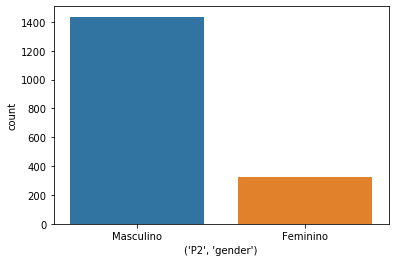

In [ ]:
sns.countplot(df_ds["('P2', 'gender')"])
plt.show()

## Escolaridade e Tipo de emprego para homens e Mulheres: Análise porcentual
<a id='escol'></a>

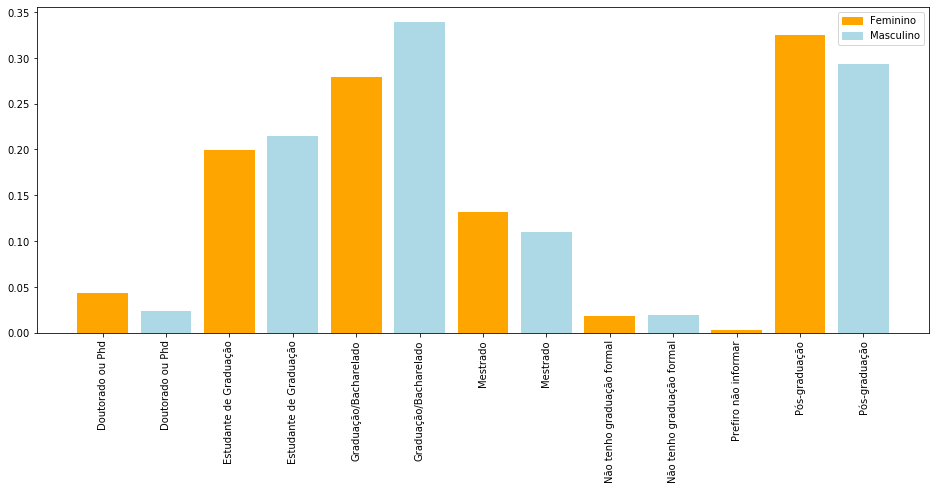

In [ ]:
col_search = "('P8', 'degreee_level')"

df_agg = df_ds.groupby([col_search,"('P2', 'gender')"]).agg({col_search:'count',})
df_agg = df_agg/df_agg.groupby(level=(1)).sum()

df_agg.reset_index(level=1, inplace=True)

plt.figure(figsize=(16,6))

colors = ['orange' if s == 'Feminino' else 'lightblue' for s in df_agg["('P2', 'gender')"]]
plt.bar(np.arange(len(df_agg.index)),df_agg[col_search],color=colors)
plt.xticks(np.arange(len(df_agg.index)),df_agg.index,rotation=90)

red_patch = mpatches.Patch(color='orange', label='Feminino')
blue_patch = mpatches.Patch(color='lightblue', label='Masculino')

plt.legend(handles=[red_patch, blue_patch])
plt.show()

In [ ]:
df_ds["('P10', 'job_situation')"].value_counts()*100/df_ds.size

Empregado (CTL)                                  0.357607
Empreendedor ou Empregado (CNPJ)                 0.077987
Estagiário                                       0.043659
Somente Estudante (graduação)                    0.028329
Desempregado, buscando recolocação               0.022996
Servidor Público                                 0.019997
Trabalho na área Acadêmica/Pesquisador           0.014998
Somente Estudante (pós-graduação)                0.011998
Freelancer                                       0.007665
Prefiro não dizer                                0.002000
Desempregado e não estou buscando recolocação    0.001000
Name: ('P10', 'job_situation'), dtype: float64

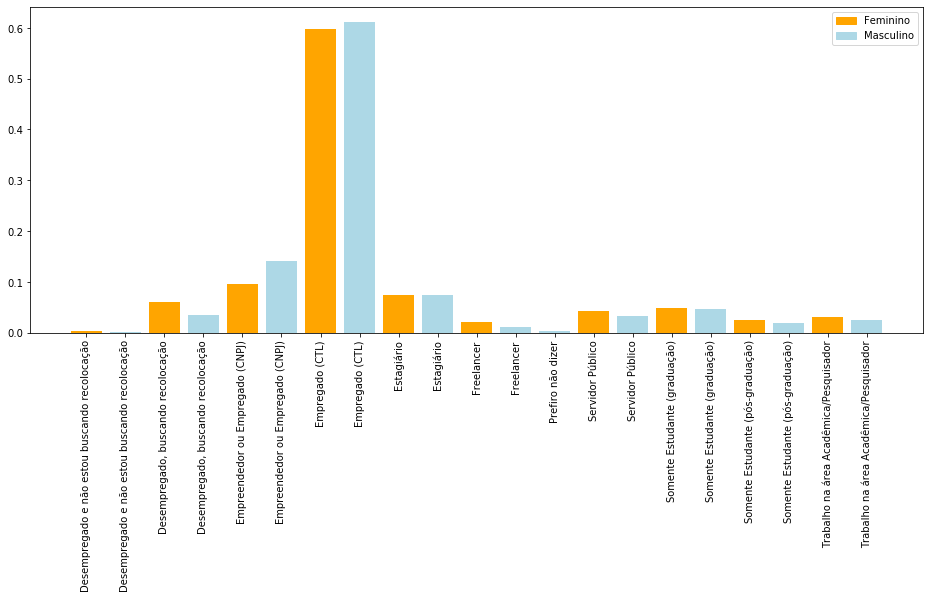

In [ ]:
col_search = "('P10', 'job_situation')"

df_agg = df_ds.groupby([col_search,"('P2', 'gender')"]).agg({col_search:'count',})
df_agg = df_agg/df_agg.groupby(level=(1)).sum()

df_agg.reset_index(level=1, inplace=True)

plt.figure(figsize=(16,6))

colors = ['orange' if s == 'Feminino' else 'lightblue' for s in df_agg["('P2', 'gender')"]]
plt.bar(np.arange(len(df_agg.index)),df_agg[col_search],color=colors)
plt.xticks(np.arange(len(df_agg.index)),df_agg.index,rotation=90)

red_patch = mpatches.Patch(color='orange', label='Feminino')
blue_patch = mpatches.Patch(color='lightblue', label='Masculino')

plt.legend(handles=[red_patch, blue_patch])
plt.show()

# Questão salarial, homens ganham mais do que as mulheres?
<a id='salario'></a>

Devido a que o salário está dado por faixa, iremos aproximar o valor de cada faixa usando a média respectiva.

In [ ]:
def transform_string(st):

    limits = [float(s[:-4].replace('.','')) for s in st.split() if s[-4:]=='/mês']
    if len(limits) == 2:
        value = np.mean(np.array(limits))
    elif limits[0]>10000:
        value = limits[0]
    else:
        value = limits[0]/2
    return value

df_ds["('P16', 'salary_range')"].fillna('0.0/mês',inplace=True)

df_ds['salary'] = df_ds.apply(lambda row: transform_string(row["('P16', 'salary_range')"]),axis=1)

df_ds[["('P16', 'salary_range')",'salary']].head()

,"('P16', 'salary_range')",salary
0,de R$ 1.001/mês a R$ 2.000/mês,1500.5
1,de R$ 2.001/mês a R$ 3000/mês,2500.5
2,de R$ 4.001/mês a R$ 6.000/mês,5000.5
3,de R$ 1.001/mês a R$ 2.000/mês,1500.5
4,de R$ 6.001/mês a R$ 8.000/mês,7000.5


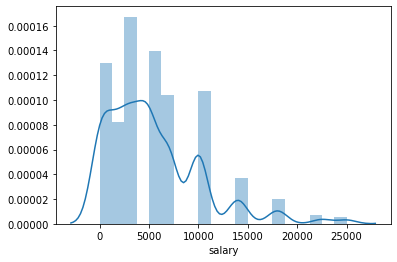

In [ ]:
sns.distplot(df_ds["salary"],bins=20)
plt.show()

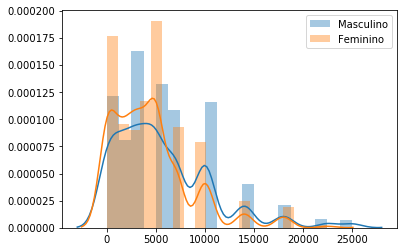

In [ ]:
sns.distplot(df_ds.loc[df_ds["('P2', 'gender')"]=='Masculino',["salary"]],bins=20,label='Masculino')
sns.distplot(df_ds.loc[df_ds["('P2', 'gender')"]=='Feminino',["salary"]],bins=20,label='Feminino')
plt.legend(loc=0)
plt.show()

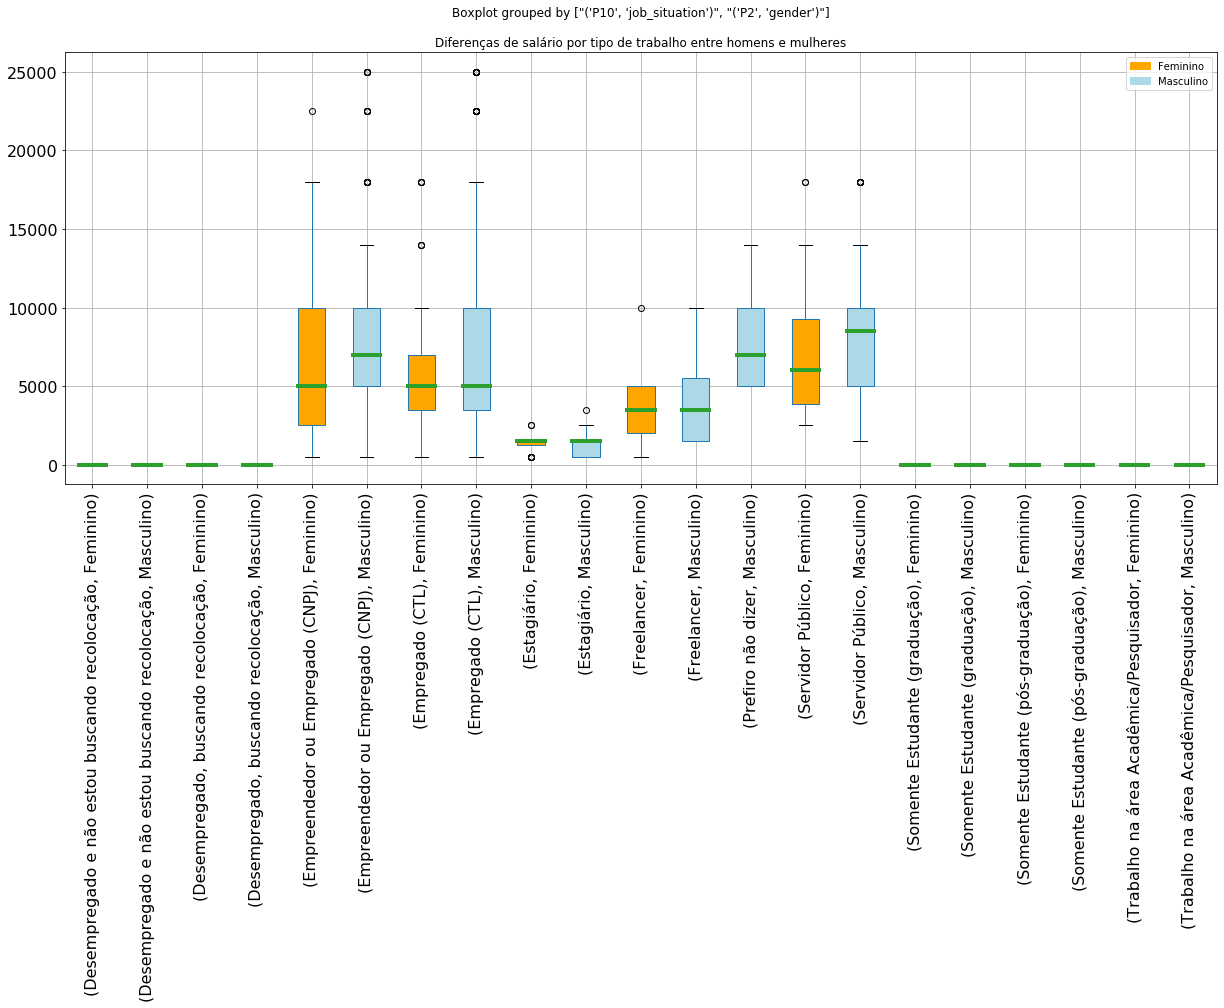

In [ ]:
col_search = "('P10', 'job_situation')"

medianprops = dict(linestyle='-', linewidth=4)
bp_dict = df_ds.boxplot(column='salary',by=[col_search,"('P2', 'gender')"],rot=90,
                        figsize=(20,8),fontsize=16,grid=True,return_type='both',patch_artist = True,
                        medianprops=medianprops)

df_agg = df_ds.groupby([col_search,"('P2', 'gender')"]).agg({col_search:'count',})
df_agg = df_agg/df_agg.groupby(level=(1)).sum()

df_agg.reset_index(level=1, inplace=True)

colors = ['orange' if s == 'Feminino' else 'lightblue' for s in df_agg["('P2', 'gender')"]]

for row_key, (ax,row) in bp_dict.iteritems():
    ax.set_xlabel('')
    for i,box in enumerate(row['boxes']):
        box.set_facecolor(colors[i])

red_patch = mpatches.Patch(color='orange', label='Feminino')
blue_patch = mpatches.Patch(color='lightblue', label='Masculino')

plt.legend(handles=[red_patch, blue_patch])
plt.title('Diferenças de salário por tipo de trabalho entre homens e mulheres')
plt.show()

Os gráficos mostram que mulheres ganham, na média, menos do que os homems em todas as vagas do mercado. Mulheres também tem uma ligeira preferência pela academia. É sabido que salários na pesquisa e academia são menores quando comparados com o mercado de trabalho, e isto pode estar relacionado com os dois pontos anteriores. Infelizmente, não temos dados de salário na parte da área acadêmica e de pesquisa para aprofundar sobre isto. Para verificar a significancia estatística destas diferenças faremos a análisa por categoria de trabalho usando estatística inferencial.

# Significância estatística das diferenças
<a id = 'significancia'></a>

In [ ]:
df_stats = df_ds.groupby("('P2', 'gender')").agg({'salary':['mean','std','count']})
mean_fem, std_fem, n_fem = df_stats.loc['Feminino']
mean_mas, std_mas, n_mas = df_stats.loc['Masculino']

media_dif = mean_mas - mean_fem

beta = 0.975 #Bicaudal
z_norm = st.norm.ppf(beta)

std_dif = np.sqrt((std_mas**2)/n_mas+(std_fem**2)/n_fem)
d = z_norm*std_dif

z = media_dif/std_dif
p_value = 1 - st.norm.cdf(z)

df_st = pd.DataFrame([['global',n_fem,n_mas,media_dif,std_dif,(media_dif-d),(media_dif+d),z,p_value],],
                     columns=['job','n feminino','n masculino','mean_dif','std_dif','inter_inf','inter_sup','z','p_value'])
df_st

,job,n feminino,n masculino,mean_dif,std_dif,inter_inf,inter_sup,z,p_value
0,global,326.0,1436.0,1233.118698,258.869216,725.744359,1740.493038,4.763481,9.514057e-07


In [ ]:
col_search = "('P10', 'job_situation')"

for job_type in ['Empregado (CTL)', 'Estagiário', 'Freelancer','Empreendedor ou Empregado (CNPJ)',
                 'Servidor Público',]:


    df_stats = df_ds.loc[df_ds[col_search]==job_type].groupby("('P2', 'gender')").agg({'salary':['mean','std','count']})
    mean_fem, std_fem, n_fem = df_stats.loc['Feminino']
    mean_mas, std_mas, n_mas = df_stats.loc['Masculino']

    media_dif = mean_mas - mean_fem

    std_dif = np.sqrt((std_mas**2)/n_mas+(std_fem**2)/n_fem)
    d = z_norm*std_dif

    z = media_dif/std_dif
    p_value = 1 - st.norm.cdf(z)

    df_st = df_st.append(pd.DataFrame([[job_type,n_fem,n_mas,media_dif,std_dif,(media_dif-d),(media_dif+d),z,p_value],],
                         columns=['job','n feminino','n masculino','mean_dif','std_dif','inter_inf','inter_sup','z','p_value']),
                         ignore_index=True)
df_st

,job,n feminino,n masculino,mean_dif,std_dif,inter_inf,inter_sup,z,p_value
0,global,326.0,1436.0,1233.118698,258.869216,725.744359,1740.493038,4.763481,9.514057e-07
1,Empregado (CTL),195.0,878.0,1168.929753,277.168914,625.688665,1712.170841,4.217391,1.235725e-05
2,Estagiário,24.0,107.0,-38.974688,130.880512,-295.495778,217.546402,-0.297788,6.170676e-01
3,Freelancer,7.0,16.0,0.071429,1351.947451,-2649.696884,2649.839741,0.000053,4.999789e-01
4,Empreendedor ou Empregado (CNPJ),31.0,203.0,1246.649213,1055.911055,-822.898425,3316.196851,1.180638,1.188732e-01
5,Servidor Público,14.0,46.0,1029.503106,1588.340192,-2083.586466,4142.592677,0.648163,2.584398e-01


# Discriminação por tempo de experiência em data science


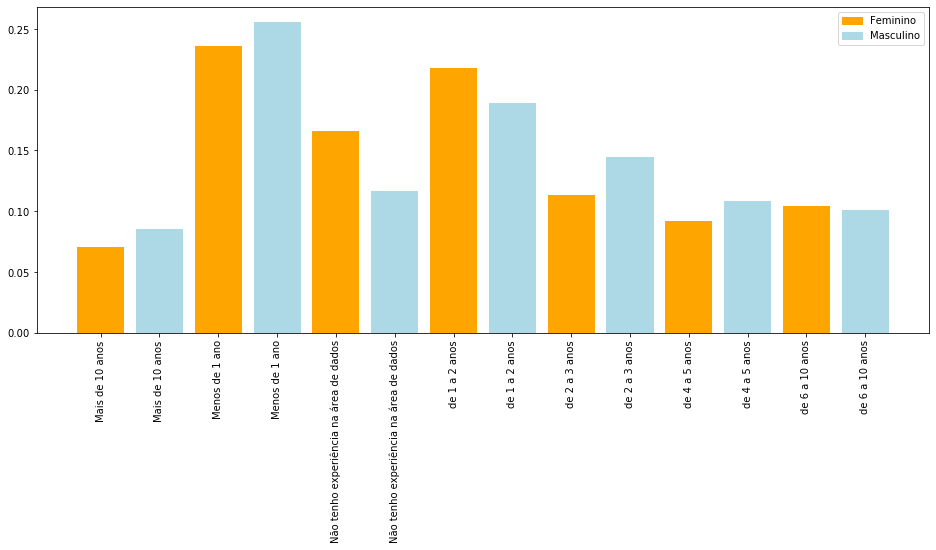

In [ ]:
col_search = "('P17', 'time_experience_data_science')"

df_agg = df_ds.groupby([col_search,"('P2', 'gender')"]).agg({col_search:'count',})
df_agg = df_agg/df_agg.groupby(level=(1)).sum()

df_agg.reset_index(level=1, inplace=True)

plt.figure(figsize=(16,6))

colors = ['orange' if s == 'Feminino' else 'lightblue' for s in df_agg["('P2', 'gender')"]]
plt.bar(np.arange(len(df_agg.index)),df_agg[col_search],color=colors)
plt.xticks(np.arange(len(df_agg.index)),df_agg.index,rotation=90)

red_patch = mpatches.Patch(color='orange', label='Feminino')
blue_patch = mpatches.Patch(color='lightblue', label='Masculino')

plt.legend(handles=[red_patch, blue_patch])
plt.show()

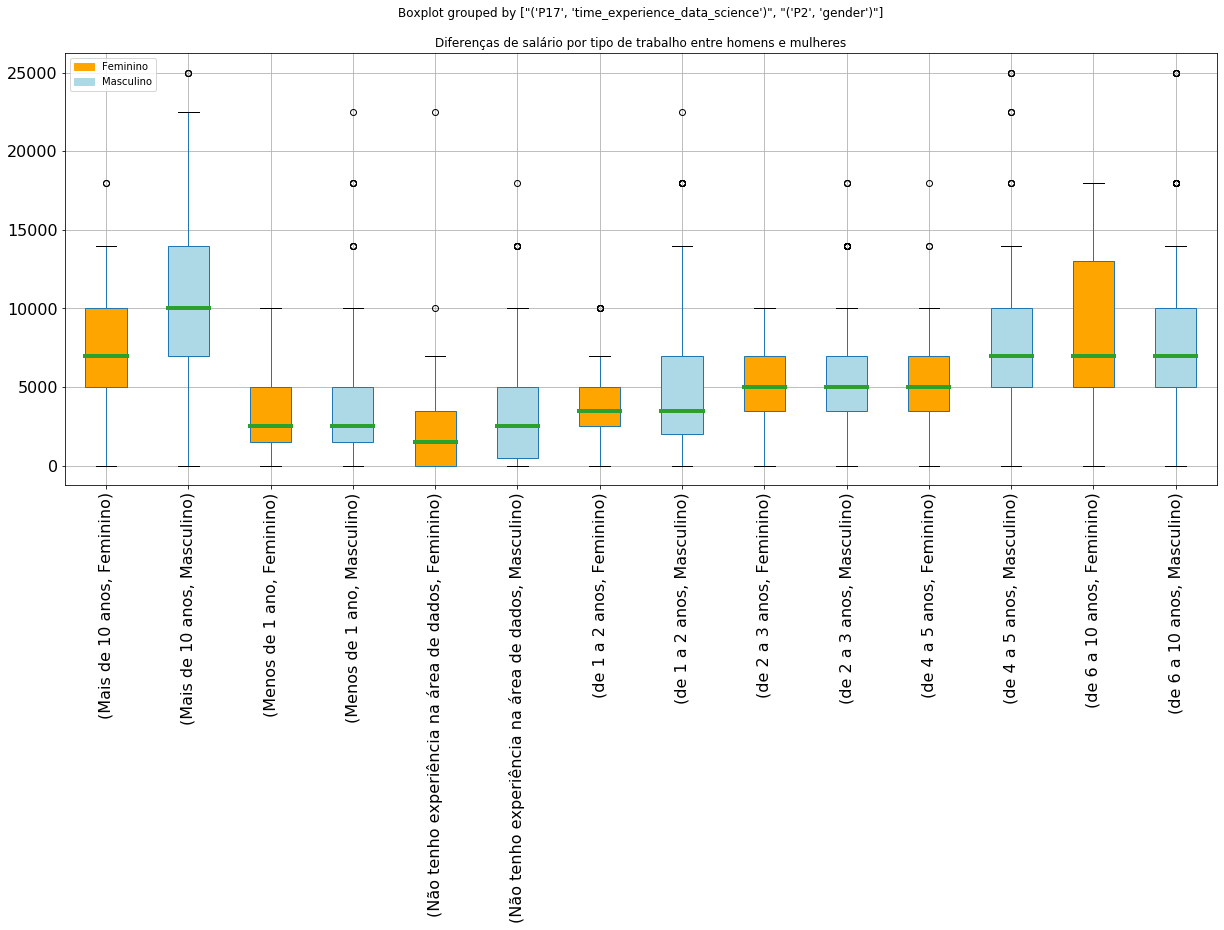

In [ ]:
medianprops = dict(linestyle='-', linewidth=4)
bp_dict = df_ds.boxplot(column='salary',by=[col_search,"('P2', 'gender')"],rot=90,
                        figsize=(20,8),fontsize=16,grid=True,return_type='both',patch_artist = True,
                        medianprops=medianprops)

df_agg = df_ds.groupby([col_search,"('P2', 'gender')"]).agg({col_search:'count',})
df_agg = df_agg/df_agg.groupby(level=(1)).sum()

df_agg.reset_index(level=1, inplace=True)

colors = ['orange' if s == 'Feminino' else 'lightblue' for s in df_agg["('P2', 'gender')"]]

for row_key, (ax,row) in bp_dict.iteritems():
    ax.set_xlabel('')
    for i,box in enumerate(row['boxes']):
        box.set_facecolor(colors[i])

red_patch = mpatches.Patch(color='orange', label='Feminino')
blue_patch = mpatches.Patch(color='lightblue', label='Masculino')

plt.legend(handles=[red_patch, blue_patch])
plt.title('Diferenças de salário por tipo de trabalho entre homens e mulheres')
plt.show()

In [ ]:
df_st = pd.DataFrame([], columns=['job','n feminino','n masculino','mean_dif','std_dif','inter_inf','inter_sup','z','p_value'])

for exp_type in ['Não tenho experiência na área de dados','Menos de 1 ano','de 1 a 2 anos','de 2 a 3 anos','de 4 a 5 anos','de 6 a 10 anos','Mais de 10 anos',]:


    df_stats = df_ds.loc[df_ds[col_search]==exp_type].groupby("('P2', 'gender')").agg({'salary':['mean','std','count']})
    mean_fem, std_fem, n_fem = df_stats.loc['Feminino']
    mean_mas, std_mas, n_mas = df_stats.loc['Masculino']

    media_dif = mean_mas - mean_fem

    std_dif = np.sqrt((std_mas**2)/n_mas+(std_fem**2)/n_fem)
    d = z_norm*std_dif

    z = media_dif/std_dif
    p_value = 1 - st.norm.cdf(z)

    df_st = df_st.append(pd.DataFrame([[exp_type,n_fem,n_mas,media_dif,std_dif,(media_dif-d),(media_dif+d),z,p_value],],
                         columns=['job','n feminino','n masculino','mean_dif','std_dif','inter_inf','inter_sup','z','p_value']),
                         ignore_index=True)
df_st

,job,n feminino,n masculino,mean_dif,std_dif,inter_inf,inter_sup,z,p_value
0,Não tenho experiência na área de dados,54.0,167.0,1127.702595,573.719839,3.232374,2252.172816,1.965598,0.024673
1,Menos de 1 ano,77.0,367.0,347.231696,333.518156,-306.451878,1000.915270,1.041118,0.148910
2,de 1 a 2 anos,71.0,271.0,900.503274,403.969172,108.738246,1692.268303,2.229139,0.012902
3,de 2 a 3 anos,37.0,207.0,1188.763546,548.704035,113.323400,2264.203693,2.166493,0.015137
4,de 4 a 5 anos,30.0,156.0,2486.589744,914.599686,694.007299,4279.172188,2.718774,0.003276
5,de 6 a 10 anos,34.0,145.0,627.434381,1004.856000,-1342.047189,2596.915951,0.624402,0.266182
6,Mais de 10 anos,23.0,123.0,2238.094556,1208.559776,-130.639077,4606.828190,1.851869,0.032022


# Conclusão
<a id='conclusao'></a>

* Depois de verificar a significância estatística das diferenças de salário para mulheres e homens por tipo de trabalho, podemos concluir que na média existe sim uma diferença de salário no mercado, sendo que mulheres ganham aproximadamente 1200 reais a menos do que os homens para vagas CLT.
* Essa diferença se extende quando olhamos para as faixas salariais. O teste estatístico mostra que, tirando tempo de experiência de menos de 1 ano e entre 6 a 10 anos onde a diferença é pequena, os homens ganham mais do que as mulheres.
* Ainda que mulheres tenham maior preferência por trabalhar na parte acadêmica e de pesquisa, em comparação com os homens, não temos como explorar questão de salários nesta área.
* Fica a questão do porque da baixa presença de mulheres em data science...

# Limitações


Ainda que se apresentou diferença nas outras áreas do mercado (diferente a CLT) esta não é conclusiva dado o baixo número de amostras por categoria e a baixa sgnificância estatística. Também é importante notar que o salário usado não é o valor real, mas sim uma aproximação dada a partir da faixa.